In [26]:
import pandas as pd
import plotly.express as px
import numpy as np

In [27]:
df = pd.read_csv(r"C:\Users\pauln\Downloads\city_market_tracker.tsv000",sep="\t")

In [28]:
df.head()

,PERIOD_BEGIN,PERIOD_END,PERIOD_DURATION,REGION_TYPE,REGION_TYPE_ID,TABLE_ID,IS_SEASONALLY_ADJUSTED,REGION,CITY,STATE,...,SOLD_ABOVE_LIST_YOY,PRICE_DROPS,PRICE_DROPS_MOM,PRICE_DROPS_YOY,OFF_MARKET_IN_TWO_WEEKS,OFF_MARKET_IN_TWO_WEEKS_MOM,OFF_MARKET_IN_TWO_WEEKS_YOY,PARENT_METRO_REGION,PARENT_METRO_REGION_METRO_CODE,LAST_UPDATED
0,2016-06-01,2016-06-30,30,place,6,9191,False,"Hagerstown, MD",Hagerstown,Maryland,...,-0.090909,0.147368,-0.063743,-0.244939,0.166667,0.166667,0.071429,"Hagerstown, MD",25180,2026-04-14 14:25:48.665 Z
1,2019-09-01,2019-09-30,30,place,6,10371,False,"Kutztown, PA",Kutztown,Pennsylvania,...,NaN,0.166667,-0.583333,NaN,0.250000,0.050000,NaN,"Reading, PA",39740,2026-04-14 14:25:48.665 Z
2,2017-09-01,2017-09-30,30,place,6,2848,False,"Capitola, CA",Capitola,California,...,-0.500000,0.250000,0.050000,-0.035714,0.200000,-0.200000,-0.050000,"Santa Cruz, CA",42100,2026-04-14 14:25:48.665 Z
3,2012-05-01,2012-05-31,30,place,6,11419,False,"McFarland, CA",McFarland,California,...,0.400000,0.222222,0.138889,0.166667,0.000000,0.000000,0.000000,"Bakersfield, CA",12540,2026-04-14 14:25:48.665 Z
4,2022-09-01,2022-09-30,30,place,6,11767,False,"Martinez, CA",Martinez,California,...,-0.500000,0.600000,0.171429,NaN,0.000000,0.000000,-1.000000,"Oakland, CA",36084,2026-04-14 14:25:48.665 Z


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6243090 entries, 0 to 6243089
Data columns (total 58 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   PERIOD_BEGIN                    object 
 1   PERIOD_END                      object 
 2   PERIOD_DURATION                 int64  
 3   REGION_TYPE                     object 
 4   REGION_TYPE_ID                  int64  
 5   TABLE_ID                        int64  
 6   IS_SEASONALLY_ADJUSTED          bool   
 7   REGION                          object 
 8   CITY                            object 
 9   STATE                           object 
 10  STATE_CODE                      object 
 11  PROPERTY_TYPE                   object 
 12  PROPERTY_TYPE_ID                int64  
 13  MEDIAN_SALE_PRICE               float64
 14  MEDIAN_SALE_PRICE_MOM           float64
 15  MEDIAN_SALE_PRICE_YOY           float64
 16  MEDIAN_LIST_PRICE               float64
 17  MEDIAN_LIST_PRICE_MOM      

In [30]:
df = df.drop(columns=[col for col in df.columns if "MOM" in col or "YOY" in col])

In [31]:
df = df.dropna()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2968874 entries, 0 to 6243088
Data columns (total 30 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   PERIOD_BEGIN                    object 
 1   PERIOD_END                      object 
 2   PERIOD_DURATION                 int64  
 3   REGION_TYPE                     object 
 4   REGION_TYPE_ID                  int64  
 5   TABLE_ID                        int64  
 6   IS_SEASONALLY_ADJUSTED          bool   
 7   REGION                          object 
 8   CITY                            object 
 9   STATE                           object 
 10  STATE_CODE                      object 
 11  PROPERTY_TYPE                   object 
 12  PROPERTY_TYPE_ID                int64  
 13  MEDIAN_SALE_PRICE               float64
 14  MEDIAN_LIST_PRICE               float64
 15  MEDIAN_PPSF                     float64
 16  MEDIAN_LIST_PPSF                float64
 17  HOMES_SOLD                      

In [33]:
df.head()

,PERIOD_BEGIN,PERIOD_END,PERIOD_DURATION,REGION_TYPE,REGION_TYPE_ID,TABLE_ID,IS_SEASONALLY_ADJUSTED,REGION,CITY,STATE,...,INVENTORY,MONTHS_OF_SUPPLY,MEDIAN_DOM,AVG_SALE_TO_LIST,SOLD_ABOVE_LIST,PRICE_DROPS,OFF_MARKET_IN_TWO_WEEKS,PARENT_METRO_REGION,PARENT_METRO_REGION_METRO_CODE,LAST_UPDATED
0,2016-06-01,2016-06-30,30,place,6,9191,False,"Hagerstown, MD",Hagerstown,Maryland,...,95.0,4.3,50.0,0.948789,0.045455,0.147368,0.166667,"Hagerstown, MD",25180,2026-04-14 14:25:48.665 Z
1,2019-09-01,2019-09-30,30,place,6,10371,False,"Kutztown, PA",Kutztown,Pennsylvania,...,6.0,1.2,149.0,1.007619,0.600000,0.166667,0.250000,"Reading, PA",39740,2026-04-14 14:25:48.665 Z
2,2017-09-01,2017-09-30,30,place,6,2848,False,"Capitola, CA",Capitola,California,...,12.0,2.0,125.0,0.941728,0.000000,0.250000,0.200000,"Santa Cruz, CA",42100,2026-04-14 14:25:48.665 Z
3,2012-05-01,2012-05-31,30,place,6,11419,False,"McFarland, CA",McFarland,California,...,9.0,1.8,56.0,1.004421,0.400000,0.222222,0.000000,"Bakersfield, CA",12540,2026-04-14 14:25:48.665 Z
4,2022-09-01,2022-09-30,30,place,6,11767,False,"Martinez, CA",Martinez,California,...,5.0,2.5,31.0,0.999191,0.500000,0.600000,0.000000,"Oakland, CA",36084,2026-04-14 14:25:48.665 Z


In [34]:
#price per state comparision

In [35]:
state_avg = df.groupby("STATE").agg({"MEDIAN_SALE_PRICE":"mean"}).sort_values(by="MEDIAN_SALE_PRICE",ascending=False).map('${:,.2f}'.format)

In [36]:
state_avg["STATE"] = state_avg.index

In [37]:
state_avg


,MEDIAN_SALE_PRICE,STATE
STATE,,
Hawaii,"$767,111.52",Hawaii
California,"$722,435.97",California
Columbia,"$656,143.31",Columbia
Montana,"$637,850.78",Montana
New Mexico,"$562,917.06",New Mexico
Colorado,"$546,832.07",Colorado
Massachusetts,"$503,695.62",Massachusetts
Connecticut,"$490,375.75",Connecticut
Utah,"$473,205.70",Utah


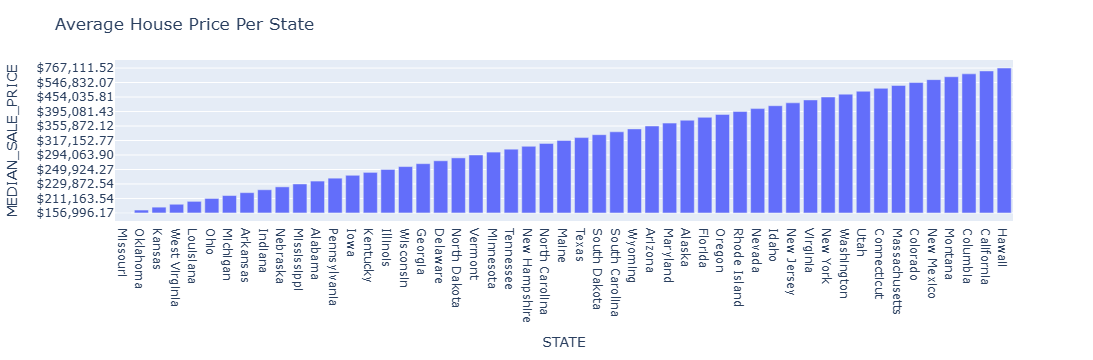

In [46]:
state_avg = state_avg.sort_values("MEDIAN_SALE_PRICE", ascending=True)

fig = px.bar(state_avg, x="STATE", y="MEDIAN_SALE_PRICE")
fig.update_layout(title={'text': 'Average House Price Per State'})
fig.show()

In [ ]:
#cities in texas sales quick?

In [51]:
tx_df = df[df["STATE"] == "Texas"]

city_avg = (
    tx_df.groupby("CITY")
    .agg({"OFF_MARKET_IN_TWO_WEEKS": "mean"})
    .sort_values(by="OFF_MARKET_IN_TWO_WEEKS", ascending=False)
)

city_avg["CITY"] = city_avg.index

city_avg

,OFF_MARKET_IN_TWO_WEEKS,CITY
CITY,,
Balcones Heights,1.0,Balcones Heights
Eureka,1.0,Eureka
McDade,1.0,McDade
Orchard,1.0,Orchard
Rio Hondo,1.0,Rio Hondo
...,...,...
Mila Doce,0.0,Mila Doce
Markham,0.0,Markham
Hays,0.0,Hays


In [60]:
city_avg = (
    df[df["STATE"] == "Texas"]
    .groupby("CITY", as_index=False)
    .agg({
        "OFF_MARKET_IN_TWO_WEEKS": "mean",
        "MEDIAN_SALE_PRICE": "mean","HOMES_SOLD":"mean"
    })
    .sort_values(
        by="OFF_MARKET_IN_TWO_WEEKS",
        ascending=False
    )
)

city_avg

,CITY,OFF_MARKET_IN_TWO_WEEKS,MEDIAN_SALE_PRICE,HOMES_SOLD
44,Balcones Heights,1.0,111500.000000,2.0
246,Eureka,1.0,247000.000000,2.0
507,McDade,1.0,346583.166667,2.0
581,Orchard,1.0,415000.000000,1.0
680,Rio Hondo,1.0,277500.000000,2.0
...,...,...,...,...
521,Mila Doce,0.0,89240.000000,1.0
497,Markham,0.0,260000.000000,1.0
327,Hays,0.0,246500.000000,1.0
762,Skidmore,0.0,205000.000000,1.0


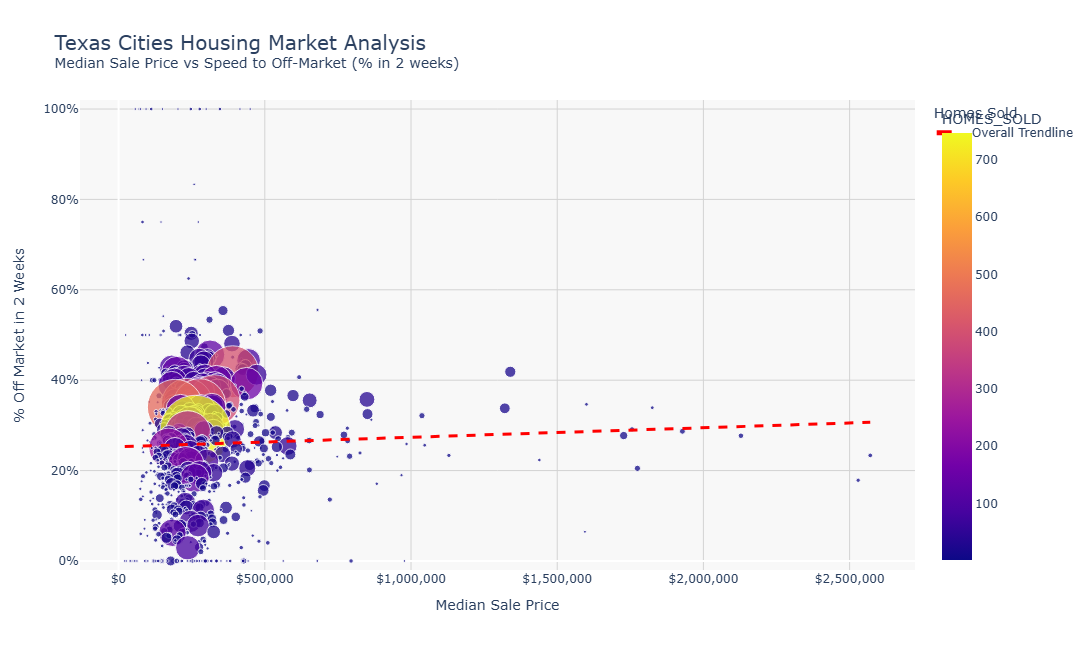

In [67]:
import plotly.express as px

fig = px.scatter(
    city_avg,
    x="MEDIAN_SALE_PRICE",
    y="OFF_MARKET_IN_TWO_WEEKS",
    size="HOMES_SOLD",
    color="HOMES_SOLD",                    # Added color by volume
    hover_name="CITY",
    hover_data={
        "MEDIAN_SALE_PRICE": "$,.0f",
        "OFF_MARKET_IN_TWO_WEEKS": ".1%",
        "HOMES_SOLD": ",.0f"
    },
    trendline="ols",
    trendline_scope="overall",
    size_max=50,
    opacity=0.75,                          # Helps with overlap
    title="Texas Cities Housing Market Analysis<br><sup>Median Sale Price vs Speed to Off-Market (% in 2 weeks)</sup>",
)

fig.update_layout(
    height=650,
    width=1000,
    title_font_size=20,
    xaxis_title="Median Sale Price",
    yaxis_title="% Off Market in 2 Weeks",
    xaxis=dict(
        tickformat="$,.0f",
        gridcolor="lightgray",
        showgrid=True
    ),
    yaxis=dict(
        tickformat=".0%",
        gridcolor="lightgray",
        range=[-0.02, 1.02]   # slight padding
    ),
    legend_title_text="Homes Sold",
    plot_bgcolor="rgba(248,248,248,1)",
)

# Improve trendline appearance
fig.update_traces(
    selector=dict(mode='lines'),
    line=dict(color='red', width=3, dash='dash')
)

# Optional: Log scale on x-axis (often better for housing prices)
# fig.update_xaxes(type="log")

fig.show()

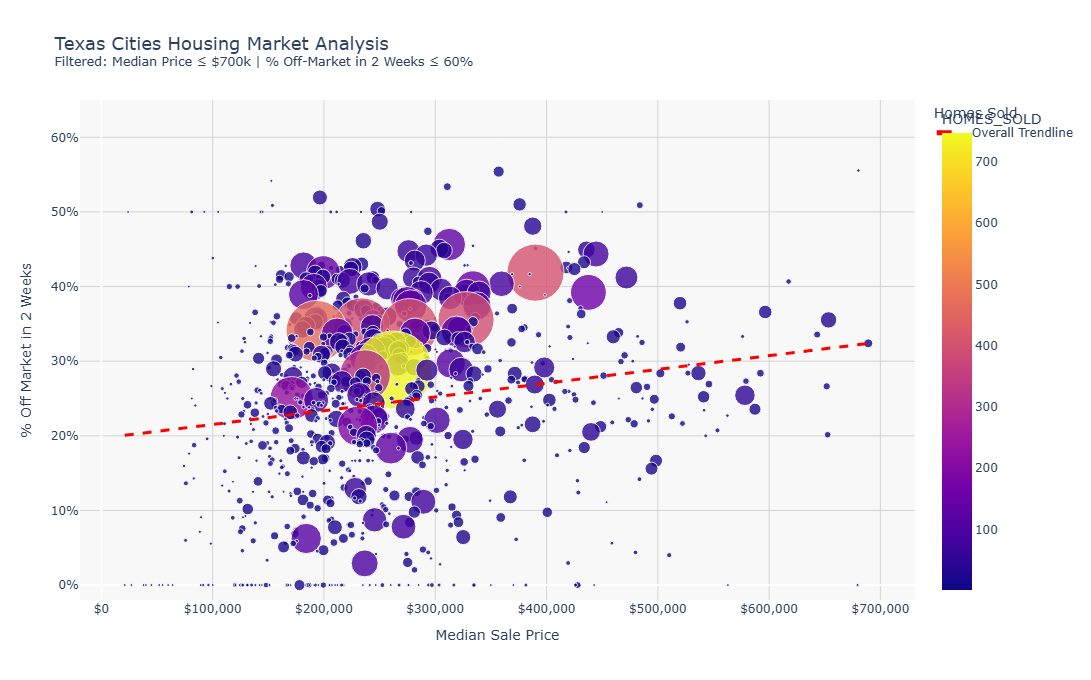

In [70]:
import plotly.express as px

# Filter the data to reduce extreme variance
filtered_df = city_avg[
    (city_avg['MEDIAN_SALE_PRICE'] <= 700_000) & 
    (city_avg['OFF_MARKET_IN_TWO_WEEKS'] <= 0.60)
].copy()

fig = px.scatter(
    filtered_df,
    x="MEDIAN_SALE_PRICE",
    y="OFF_MARKET_IN_TWO_WEEKS",
    size="HOMES_SOLD",
    color="HOMES_SOLD",
    hover_name="CITY",
    hover_data={
        "MEDIAN_SALE_PRICE": "$,.0f",
        "OFF_MARKET_IN_TWO_WEEKS": ".1%",
        "HOMES_SOLD": ",.0f"
    },
    trendline="ols",
    trendline_scope="overall",
    size_max=55,
    opacity=0.8,
    title="Texas Cities Housing Market Analysis<br><sup>Filtered: Median Price ≤ $700k | % Off-Market in 2 Weeks ≤ 60%</sup>",
)

fig.update_layout(
    height=680,
    width=1050,
    title_font_size=18,
    xaxis_title="Median Sale Price",
    yaxis_title="% Off Market in 2 Weeks",
    xaxis=dict(
        tickformat="$,.0f",
        gridcolor="lightgray",
    ),
    yaxis=dict(
        tickformat=".0%",
        gridcolor="lightgray",
        range=[-0.02, 0.65]
    ),
    plot_bgcolor="rgba(248,248,248,1)",
    legend_title_text="Homes Sold",
)

# Style the trendline
fig.update_traces(
    selector=dict(mode='lines'),
    line=dict(color='red', width=3, dash='dash')
)

fig.show()

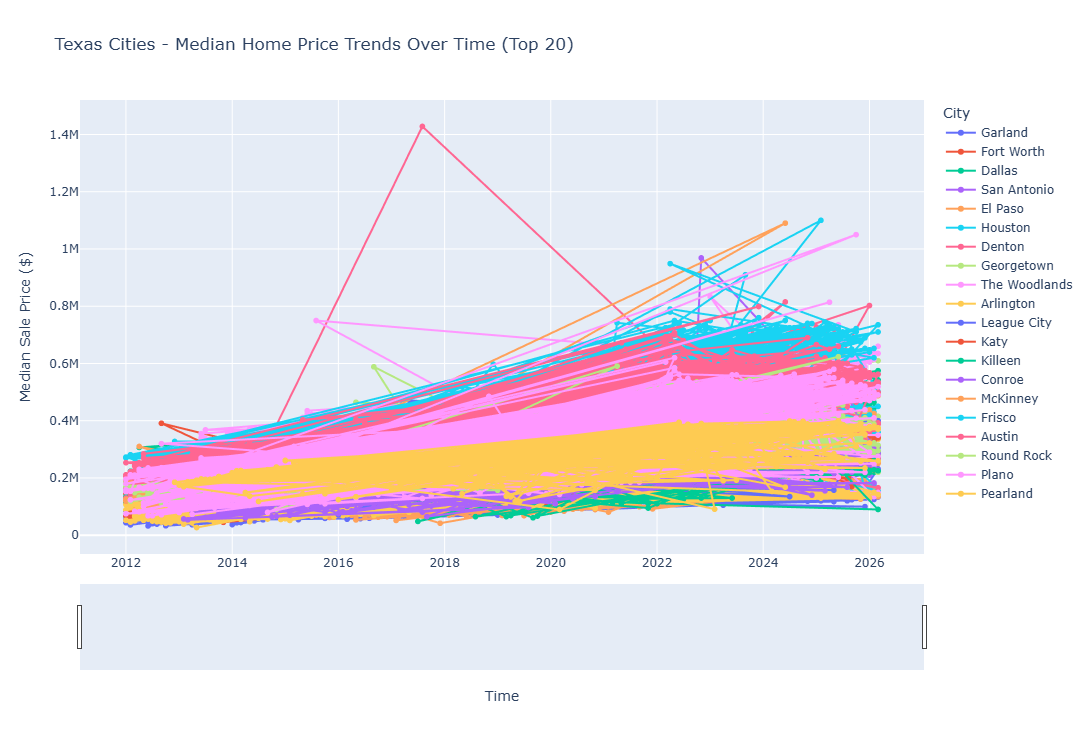

In [75]:
import plotly.express as px

# Prepare data
df_tx = df[df['STATE'] == 'Texas'].copy()
df_tx['Month'] = pd.to_datetime(df_tx['PERIOD_BEGIN']).dt.strftime('%Y-%m')

# Top cities
top_cities = df_tx.groupby('CITY')['HOMES_SOLD'].sum().nlargest(20).index
df_top = df_tx[df_tx['CITY'].isin(top_cities)]

fig = px.line(
    df_top,
    x='Month',
    y='MEDIAN_SALE_PRICE',
    color='CITY',
    hover_data=['HOMES_SOLD', 'OFF_MARKET_IN_TWO_WEEKS'],
    title="Texas Cities - Median Home Price Trends Over Time (Top 20)",
    markers=True
)

fig.update_layout(
    height=750,
    xaxis_title="Time",
    yaxis_title="Median Sale Price ($)",
    legend_title="City",
    hovermode="x unified"
)

# Add range slider
fig.update_xaxes(rangeslider_visible=True)

fig.show()

In [ ]:
#top 20 city price increase from 2012-2026

In [76]:
top_20_price = (df[df['STATE'] == 'Texas']
                .groupby('CITY')['MEDIAN_SALE_PRICE']
                .median()
                .sort_values(ascending=False)
                .head(20))

print(top_20_price)

CITY
Piney Point Village      2378375.0
Westlake                 2112500.0
Hunters Creek Village    1980000.0
Bunker Hill Village      1774000.0
Highland Park            1550000.0
Barton Creek             1512002.5
Southside Place          1410000.0
West Lake Hills          1394000.0
Westover Hills           1384200.0
Rollingwood              1321459.0
West University Place    1297500.0
University Park          1270250.0
Hedwig Village           1120000.0
Lost Creek               1120000.0
Caney City                977500.0
Spring Valley Village     973500.0
Morgan's Point            947500.0
Hill Country Village      919500.0
Hilshire Village          888000.0
Bellaire                  880250.0
Name: MEDIAN_SALE_PRICE, dtype: float64
